<a href="https://colab.research.google.com/github/aayushchourasia123/Machine-Learning/blob/main/missing%20indicator%20%26%20random%20sample%20imputation/random_sample_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#numeric data
df=pd.read_csv('/content/train.csv',usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [ ]:
df.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [ ]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
x_train['age_imputed']=x_train['Age']
x_test['age_imputed']=x_test['Age']

In [ ]:
x_train

,Age,Fare,age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


In [ ]:
x_train['age_imputed'][x_train['age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum(),random_state=0).values
x_test['age_imputed'][x_test['age_imputed'].isnull()]=x_test['Age'].dropna().sample(x_test['Age'].isnull().sum(),random_state=0).values

/tmp/ipython-input-100-2875298385.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['age_imputed'][x_train['age_imputed'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum(),random_state=0).values
/tmp/ipython-in

In [ ]:
x_train

,Age,Fare,age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,23.0
493,71.0,49.5042,71.0
527,NaN,221.7792,60.0


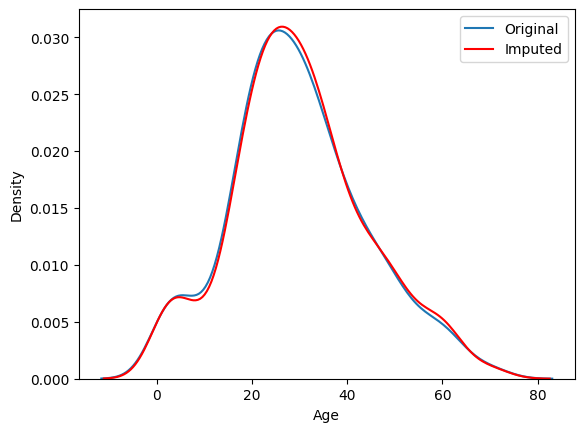

In [ ]:
sns.kdeplot(x_train['Age'])
sns.kdeplot(x_train['age_imputed'],color='red')

plt.legend(['Original','Imputed'])
plt.show()

In [ ]:
 print('original variable variance', x_train['Age'].var())
 print('imputed variable variance', x_train['age_imputed'].var())

original variable variance 204.3495133904614
imputed variable variance 204.96152644874317


In [ ]:
x_train.cov()

,Age,Fare,age_imputed
Age,204.349513,71.512440,204.349513
Fare,71.512440,2368.246832,63.137063
age_imputed,204.349513,63.137063,204.961526


<Axes: >

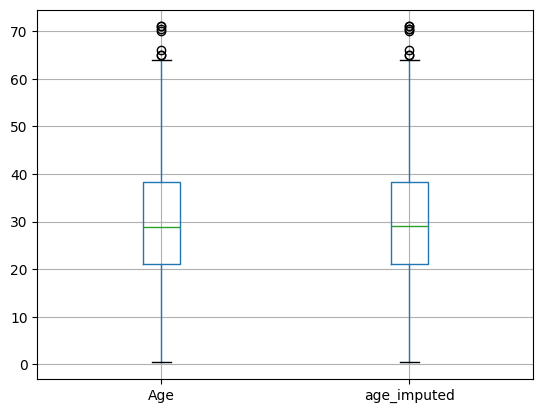

In [ ]:
x_train[['Age','age_imputed']].boxplot()

In [ ]:
#categorical data
df=pd.read_csv('/content/housing dataset.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [ ]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [ ]:
x=df
y=df['SalePrice']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
x_train['GarageQual_imputed']=x_train['GarageQual']
x_test['GarageQual_imputed']=x_test['GarageQual']

x_train['FireplaceQu_imputed']=x_train['FireplaceQu']
x_test['FireplaceQu_imputed']=x_test['FireplaceQu']

In [ ]:
x_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [ ]:
x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()]=x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum(),random_state=0).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()]=x_test['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum(),random_state=0).values

x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()]=x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum(),random_state=0).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()]=x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum(),random_state=0).values

/tmp/ipython-input-112-859514796.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()]=x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum(),random_stat

In [ ]:
temp=pd.concat(
    [x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()),
     x_train['GarageQual_imputed'].value_counts()/len(x_train)],
    axis=1
)
temp.columns=['original','imputed']
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [ ]:
temp=pd.concat(
    [x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu'].dropna()),
     x_train['FireplaceQu_imputed'].value_counts()/len(x_train)],
    axis=1
)
temp.columns=['original','imputed']
temp

,original,imputed
Gd,0.494272,0.497432
TA,0.412439,0.410103
Fa,0.040917,0.041096
Po,0.027823,0.026541
Ex,0.024550,0.024829


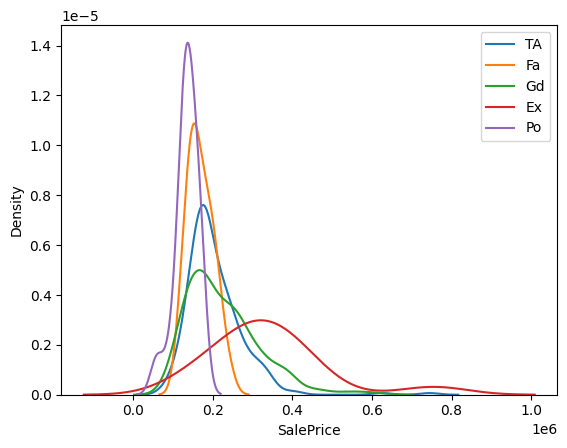

In [ ]:

for category in x_train['FireplaceQu'].dropna().unique():
  sns.kdeplot(x_train[x_train['FireplaceQu']==category]['SalePrice'],label=category)
plt.legend()
plt.show()

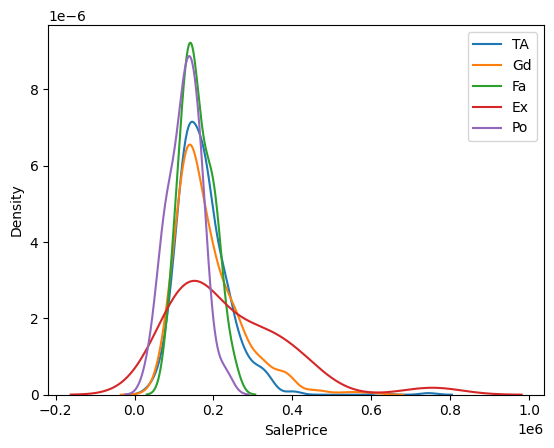

In [ ]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
  sns.kdeplot(x_train[x_train['FireplaceQu_imputed']==category]['SalePrice'],label=category)
plt.legend()
plt.show()